In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd

In [2]:
# Forming expectations from a distribution
# One of the most helpful way to understand a dataset is to visualize its distribution.
# Let's start with a data generator that simulates restaurant ratings (1 star to 5 stars), which we can draw samples from. 
# Which restaurant would you rather eat at? How did you decide this?
#   1. look at where the distribution peak
#   2. look at the shape of the distribution
# In other words, we look at the summary statistics.

# Set the random seed for reproducibility
rng = np.random.default_rng(2)

def restaurant_ratings_generator(a = 1, n = 500, loc = 1, scale = 1):
    """
    skewnorm - is a data generator function that generate a skew normal curve
    a - control the shape of the distribution
    size - number of random numbers to generate
    n - number of reviews/observations
    loc - mean value or the center of the curve
    scale - std deviation of the curve
    """
    samples = stats.skewnorm.rvs(a, size=n, loc=loc, scale = scale, random_state=rng)
    samples = np.round(samples)
    samples = np.clip(samples, 1, 5)
    return samples

def plot_ratings(ratings, restaurant_name):
    bins=[-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5]
    title_str = restaurant_name + ' Ratings'
    plt.hist(ratings,bins)
    plt.xticks(range(6))
    plt.xlim([1, 6])
    plt.xlabel('Rating')
    plt.ylabel('Frequency')
    plt.title(title_str)
    plt.show()

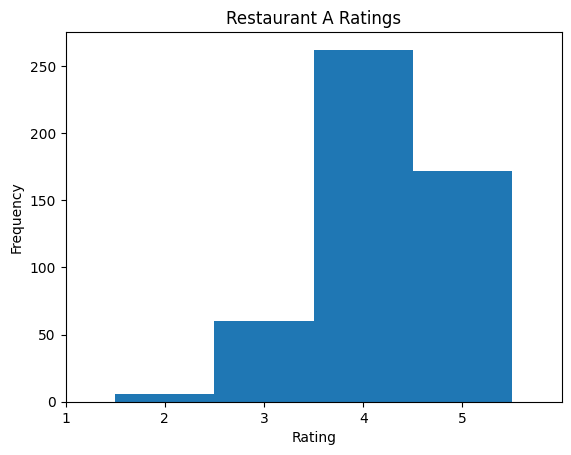

np.float64(4.2)

In [3]:
restaurant_a_ratings = restaurant_ratings_generator(a = -4, n = 500, loc = 5)
plot_ratings(restaurant_a_ratings, "Restaurant A")
restaurant_a_ratings.mean()

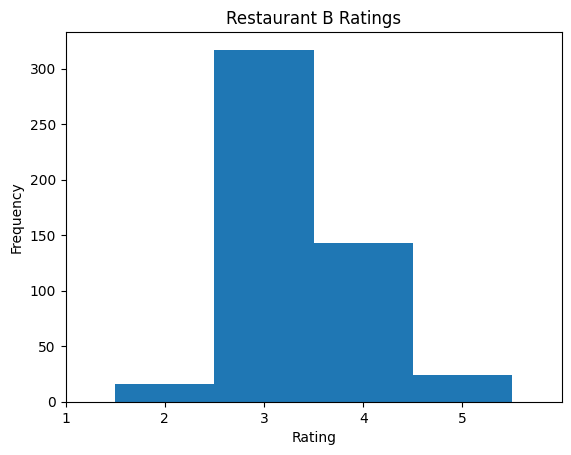

np.float64(3.35)

In [4]:
restaurant_b_ratings = restaurant_ratings_generator(a = 10, n = 500, loc = 2.5)
plot_ratings(restaurant_b_ratings, "Restaurant B")
restaurant_b_ratings.mean()

In [5]:
# Generating summary statistics about a distribution
# Visually inspecting a distribution is a crucial step for understanding dating. We can formalize some of the big patterns using summary statistics.
n_observations = restaurant_a_ratings.size
minimum_rating = np.min(restaurant_a_ratings)
maximum_rating = np.max(restaurant_a_ratings)
mean_rating = np.mean(restaurant_a_ratings)

# print these values with text
print(f"Number of observations: {n_observations}")
print(f"Minimum rating: {minimum_rating}")
print(f"Maximum rating: {maximum_rating}")
print(f"Mean rating: {mean_rating}")

Number of observations: 500
Minimum rating: 2.0
Maximum rating: 5.0
Mean rating: 4.2


In [6]:
# alternatively,
stats.describe(restaurant_a_ratings)

DescribeResult(nobs=np.int64(500), minmax=(np.float64(2.0), np.float64(5.0)), mean=np.float64(4.2), variance=np.float64(0.47294589178356705), skewness=np.float64(-0.5032770846901479), kurtosis=np.float64(0.014938236139041106))

In [7]:
stats.describe(restaurant_b_ratings)

DescribeResult(nobs=np.int64(500), minmax=(np.float64(2.0), np.float64(5.0)), mean=np.float64(3.35), variance=np.float64(0.3882765531062124), skewness=np.float64(0.7804182640820403), kurtosis=np.float64(0.4805827263267419))

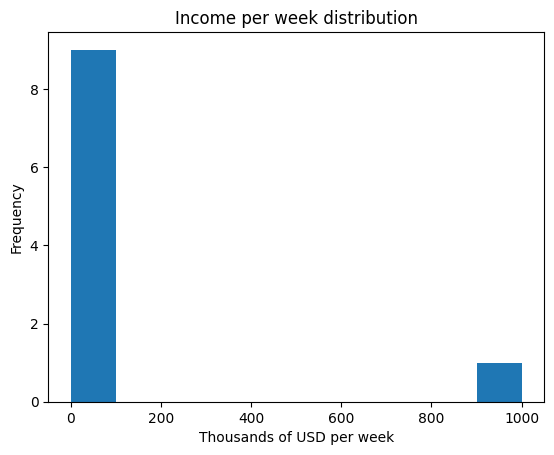

In [8]:
# Choosing the right descriptive statistics
# Sometimes, we have to be careful when choosing the statistic that is appropriate to describe our data. Consider a very long-tailed distribution:

# Generate samples from a power law distribution
neighbor_earnings  = stats.lognorm.rvs(s=1, size = 9, random_state = rng) # generate data for a logarithmic curve
millionaire_earnings = np.array([1000])
income = np.append(neighbor_earnings, millionaire_earnings)

# Plot the histogram of the samples
plt.hist(income)
plt.xlabel('Thousands of USD per week')
plt.ylabel('Frequency')
plt.title('Income per week distribution')
plt.show()

In [9]:
# The above shows the household income in the neightborhood. We can see that a majority falls in the 0-100 USD/week range, and one household has a very high income in the neighborhood.
# This can skew our interpretation when we just look at the mean value of the distribution. The median value would be a better figure to use if we want to know the typical income in
# the neighborhood. The median is more resistant to extreme values.
mean_income = np.mean(income)
median_income = np.median(income)

print(f"Mean income: {mean_income}")
print(f"Median income: {median_income}")

Mean income: 103.42678479662474
Median income: 3.2403019005955738


In [10]:
# Reasoning About Probability from a Distribution

# When we see a data distribution, we can use it to put observations in context. Let's see how.
# Since we're going to be generating data, we'll start by setting a random seed for reproducibility.

rng = np.random.default_rng(2)

In [11]:
# We're going to make some simulated data about people's heights. In most populations, height is normally distributed. The distribution of heights has varied over time- and by place- 
# but we can look at one especially large dataset drawn from samples in Europe, North America, Australia, and East Asia.
# In this dataset, for participants whose sex is female, the average height was 164.7 cm with a standard deviation of 7.07 cm.

height_mu = 164.7
height_sigma = 7.1
n_samples = 1000

# Generate the data for a normal distribution
data = stats.norm.rvs(loc=height_mu, 
                      scale=height_sigma, 
                      size=n_samples, 
                      random_state=rng)

# Create a dataframe with the data
df = pd.DataFrame({'height': data})
df

,height
0,166.042279
1,160.988486
2,161.767249
3,147.365582
4,177.477922
...,...
995,158.225072
996,158.185416
997,173.219978
998,152.850010


Text(0.5, 0, 'Height (cm)')

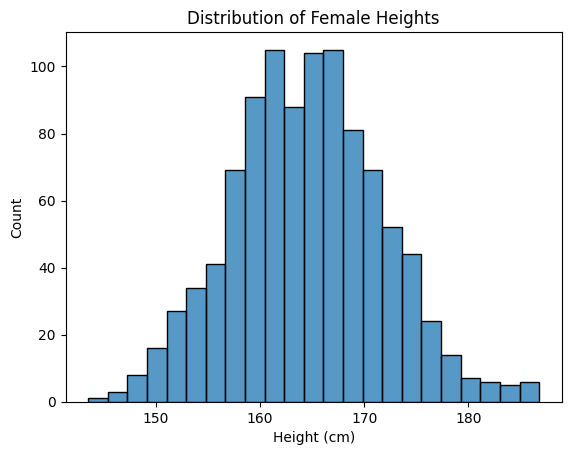

In [12]:
# Visualize the data distribution

sns.histplot(data=df, x='height')
plt.title("Distribution of Female Heights")
plt.xlabel("Height (cm)")

In [13]:
# Thinking in percentiles

# One way to think about individual observations in context of the whole distribution is to think about percentiles. For example: let's say we meet someone 
# who is 172 cm tall. What percent of people in our sample would be shorter than 172 cm? 

stats.percentileofscore(df.height, 172)

# about 84.7% of people are shorter than 172 cm.

np.float64(84.7)

In [14]:
# What if we met someone even taller- 180 cm? Now what percent of people in our sample are even shorter than them?
stats.percentileofscore(df.height, 180)

# about 97.9% of the observed peoples are shorter than 180 cm.

np.float64(97.9)

In [15]:
# What if we met someone who is 150 cm tall? What percent of our sample is shorter than that?
stats.percentileofscore(df.height, 150)

# about 1.8% % of the observed peoples are shorter than 150 cm.

np.float64(1.8)

In [16]:
# Thinking about the range of a distribution

# Another way of reasoning about what observations might be surprising, versus typical, is to think about the width of a distribution. There are a few ways 
# to do this in numbers (we've already mentioned one, the standard deviation). It tells us about the variability of the observed data.

# First up: something called the interquartile range. This is defined as the difference between the upper and lower quartiles, Q1 and Q2.
# What's a quartile? Well, the lower quartile is the value at the 25th percentile of our data distribution. We line up the people from shortest to tallest
# and ask for the tallest in the first 25 % of the people. The median, is the value at the 50th percentile. 
# What do you think the upper quartile is? 

q1 = stats.scoreatpercentile(df.height, 25)
q1


np.float64(159.67506803536526)

In [17]:
q3 = stats.scoreatpercentile(df.height, 75)
q3

np.float64(169.34196728265724)

In [18]:
# interquartile range
iqr = q3 - q1
iqr

np.float64(9.66689924729198)

In [19]:
# Luckily, we don't always have to do this by hand. There's a nice compact function in scipy.stats. 
stats.iqr(df.height)

np.float64(9.66689924729198)

<Axes: xlabel='height'>

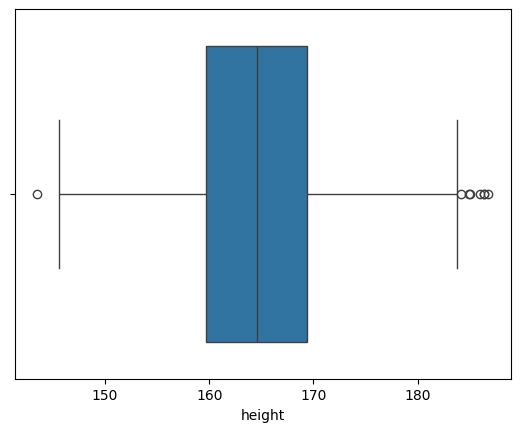

In [20]:
# Something nice about the IQR is that if we make a boxplot, by default, we'll see the quartiles, median, and IQR represented:

sns.boxplot(data=df, x='height')

In [21]:
# We can generalize the idea of the interquartile range a bit. We don't have to fix the endpoints at the 25th and 75th percentiles- we could place them anywhere. 
# The standard IQR covers 50% of the data as the range is from 25% to 75%. Sometime we want a wider range.
# What if we wanted a range covering the middle 50% of our distribution, we wanted the middle 95%?

lower_bound_percentile = (100 - 95)/2
lower_bound_percentile

2.5

In [22]:
upper_bound_percentile = 100 - lower_bound_percentile
upper_bound_percentile

97.5

In [23]:
# Now let's convert these bounds into heights- what height corresponds to the lower bound (the 2.5th percentile)?

height_at_lower_bound = stats.scoreatpercentile(df.height, lower_bound_percentile)
height_at_lower_bound

np.float64(150.90064693718213)

In [24]:
height_at_upper_bound = stats.scoreatpercentile(df.height, upper_bound_percentile)
height_at_upper_bound

np.float64(178.25588511564274)

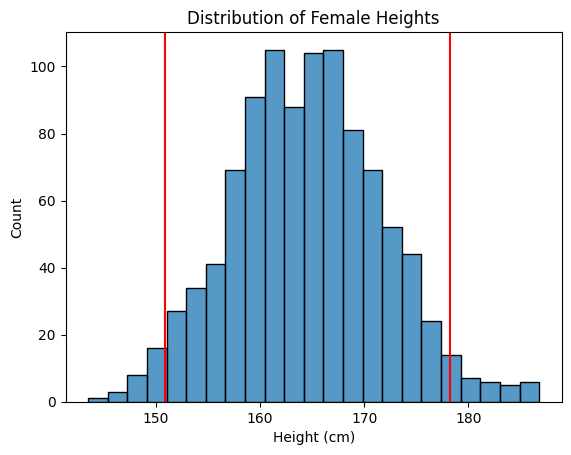

In [25]:
# We can mark these values on our visualization of the data distribution, which is often a helpful guide.
# This means 95% of our data falls in the range bounded by the vertical lines. 

sns.histplot(data=df, x='height')
plt.title("Distribution of Female Heights")
plt.xlabel("Height (cm)")
plt.axvline(height_at_lower_bound, color='red')
plt.axvline(height_at_upper_bound, color='red')

Text(0.5, 0, 'Height (cm)')

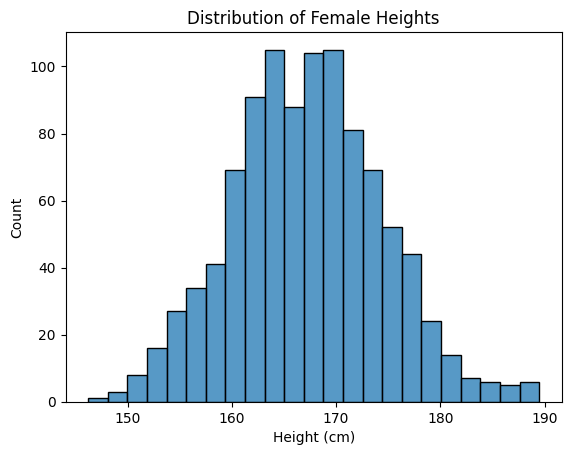

In [26]:
# Special Properties of Normal Distributions


# Let's continue on with our example about heights. We'll simulate an experiment where I have randomly sampled 1000 people whose sex is female and measured their height. 
n_samples = 1000

# Set random seed for reproducibility
rng = np.random.default_rng(2)

# Generate the data 
data = stats.norm.rvs(loc=167.4, 
                      scale=7.1, 
                      size=n_samples, 
                      random_state=rng)

# Create a dataframe with the data
df = pd.DataFrame({'height': data})


# And let's visualize the distribution, as we almost always will do when we're inspecting a dataset. 
sns.histplot(data=df, x='height')
plt.title("Distribution of Female Heights")
plt.xlabel("Height (cm)")


# To reason about how much spread this distribution has, we could calculate percentiles, like before. But, we know something about the data. 
# We know that the Heights are normally distributed. And that means we can combine our actual measurements with what we know about normal distributions from theory.


In [27]:
# If we know the mean of our distribution and its standard deviation, we can let the scipy.stats module take care of everything else!
sample_mu = df.height.mean()
print("The sample mean is", sample_mu)
sample_sigma = df.height.std()
print("The sample standard deviation is", sample_sigma)

The sample mean is 167.2408956694359
The sample standard deviation is 7.194673378838189


<Axes: xlabel='height', ylabel='Density'>

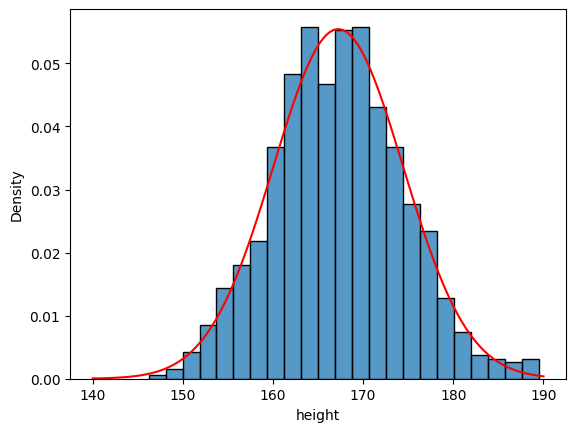

In [28]:
# Now lets use those values to visualize the theoretical distribution: 
x = np.linspace(140, 190, 100)
y = stats.norm.pdf(x, sample_mu, sample_sigma) 
# Calculate the probability density function (PDF) for the normal distribution
pdf = pd.DataFrame({"height": x, "probability": y})

# Plot the PDF in seaborn
sns.histplot(data=df, x='height', stat='density') 
# Add the lineplot over this
sns.lineplot(data=pdf, x='height', y='probability', color='red')

# The red line is our theoretical normal distribution based on the calculated mean and sigma.

In [29]:
# The normal distribution is special in statistics. It has a nice relationship between a measure of width- its standard deviation- and percentiles. 

# We can use the standard deviation to partition up the normal distribution. Without doing any programming, see if you can calculate:
# z is the number of standard deviation (sigma)
    # What proportion of the area under the curve is above z = 2? meaning what % of our data is above z = 2?
    # What proportion of the area under the curve is between z = -1 and z = 1?
    # What is the 2.5th percentile of the area under the normal curve?

# But for our data, we don't have z-scores - we have heights in centimenters. Luckily, there's a formula to make the conversion: z = (x - u) / sigma
# We can calculate this by hand using numpy:

df['z'] = (df.height - sample_mu) / sample_sigma
df.head()

,height,z
0,168.742279,0.208680
1,163.688486,-0.493756
2,164.467249,-0.385514
3,150.065582,-2.387226
4,180.177922,1.798140


In [30]:
# And even more handily, there is a function that will do the calculation for us in scipy.stats:
df['z2'] = stats.zscore(df.height)
df.head()

# note the value in Z and Z2 are the same

,height,z,z2
0,168.742279,0.208680,0.208784
1,163.688486,-0.493756,-0.494003
2,164.467249,-0.385514,-0.385707
3,150.065582,-2.387226,-2.388421
4,180.177922,1.798140,1.799039


In [31]:
# It's common to use standard deviations to describe how ordinary or extraordinary a particular observation is. If a given observation is 1 standard 
# deviation above the mean- is it noteworthy? 


<Axes: xlabel='x', ylabel='y'>

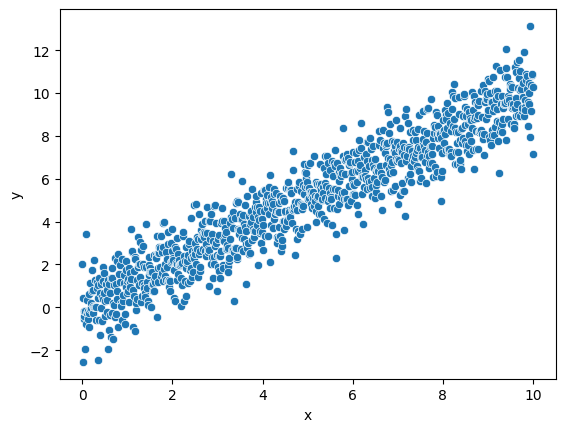

In [32]:
# Linear Relationship in Data

# Oftentimes in data analysis, we will be interested in not just one variable, but two or more. And in particular, we'll want to understand the relationships 
# between those variables- which we formalize by studying the joint distribution of those variables.
# Here, we'll look at one of the most classic examples of a joint distribution for variable pairs (x,y) - when y is a linear function of x. 

# The linear data-generating process
# So far, we've used simulations to generate data from various probability density functions. This approach also gives us a window into the "model" that is assumed 
# to underlie data when a linear relationship is present. Let's take a look.

rng = np.random.default_rng(3)

# generate x values linearly spaced from 0 to 10
n = 1000
x = np.linspace(0, 10, n) # generate 1000 linearly spaced numbers of values from 0 to 10.
y = x  + stats.norm.rvs(size = n, random_state=rng) # add random noise => y = 1x + 0 + e

# Then we can save our data in a dataframe and plot it.
df = pd.DataFrame({'x': x, 'y': y})
sns.scatterplot(x='x', y='y', data=df)

Text(0, 0.5, 'f(x)')

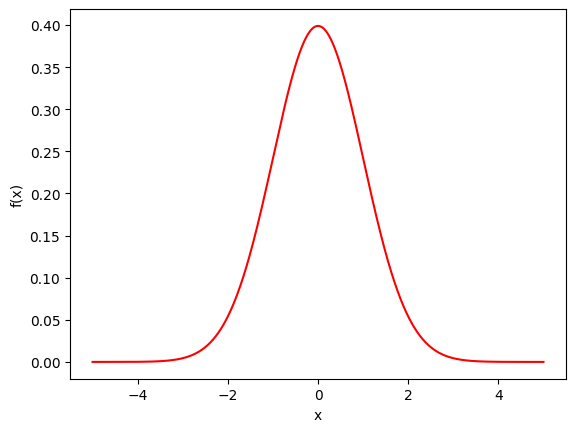

In [33]:
# Why does this work? Remember the equation for a line: y = mx + b
# What exactly was our code again? We created as a series of linearly spaced values from 0 to 10. And is each value of , plus a randomly generated term. 
# What are and ? Let's think about this for a second.

# But the randomly generated term in our code doesn't line up with our formula for a line. How would we write this in algebra?  y = mx + b + e

# e is mathematical notation for "error", or the noisiness that is baked into our data generating process. Let's look at what happens when we play with 
# the parameters of that random process. Recall that this was our original code:
y = x  + stats.norm.rvs(size = n, random_state=rng)   # y = 1x + 0 + e

# The random values here are drawn from a normal distribution. We can use the scipy.stats module's built-in .pdf() method to access 
# the probability density function for this distribution.
pdf_x = np.linspace(-5, 5, 1000)
pdf_y = stats.norm.pdf(pdf_x) 

# Make a dataframe
pdf = pd.DataFrame({"x": pdf_x, "density_1": pdf_y})

# Plot it
sns.lineplot(data=pdf, x='x', y='density_1', color='red')
plt.ylabel('f(x)')


# Notes:
# 1. The average of all the randomly generated x values is zero.
# 2. default std deviation = 1



Text(0, 0.5, 'f(x)')

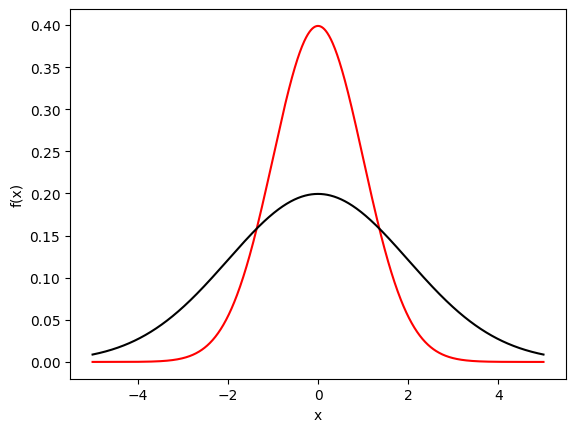

In [34]:
# We could make this density function wider by increasing the standard deviation (right now, it is parameterized with the default value = 1).
pdf['density_2'] = stats.norm.pdf(pdf_x, scale = 2) # std deviation = 2

sns.lineplot(data=pdf, x='x', y='density_1', color='red')
sns.lineplot(data=pdf, x='x', y='density_2', color='black')
plt.ylabel('f(x)')


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_22766/26094774.py:8: SyntaxWarning: invalid escape sequence '\s'
  axs[0].set_title('$\sigma$ = 1')
/tmp/ipykernel_22766/26094774.py:13: SyntaxWarning: invalid escape sequence '\s'
  axs[1].set_title('$\sigma$ = 2')


(-5.0, 17.0)

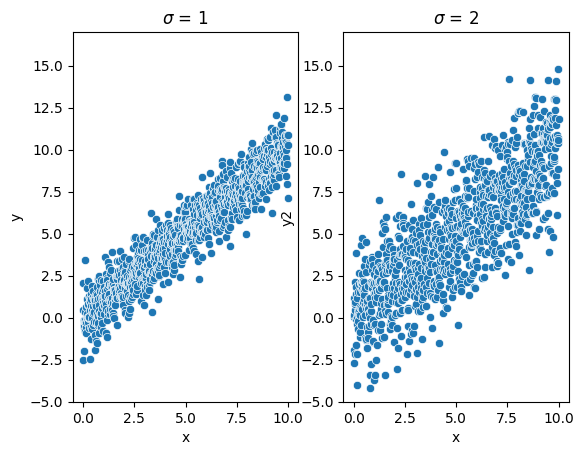

In [35]:
# Now let's see what happens when we use this wider probability density function to generate our linear data. We'll start with data generation...
df['y2'] = x  + stats.norm.rvs(size = n, scale = 2, random_state=rng)

# And now let's visualize.
fig, axs = plt.subplots(1, 2)

# Plot on the first subplot
axs[0].set_title('$\sigma$ = 1')   
sns.scatterplot(x='x', y='y', data=df, ax=axs[0])
axs[0].set_ylim(-5,17)

# Plot on the second subplot
axs[1].set_title('$\sigma$ = 2')
sns.scatterplot(x='x', y='y2', data=df, ax=axs[1])
axs[1].set_ylim(-5,17)


In [36]:
# Estimating the line that best describes data

# If we have data that appears to contain a linear relationship between variables, but we don't have access directly to the data-generating process, 
# we can use linear regression to try to recover an estimate of the slope and intercept of a line that models the data-generating process. 
# Let's try with the data we generated above.
results1 = stats.linregress(df.x, df.y)
results1

LinregressResult(slope=np.float64(0.9971477168196405), intercept=np.float64(0.05274057166969204), rvalue=np.float64(0.9440405551580225), pvalue=np.float64(0.0), stderr=np.float64(0.01102790296059752), intercept_stderr=np.float64(0.0636855587760155))

In [37]:
# And let's compare to our data when we used a wider normal distribution in our generation process.
results2 = stats.linregress(df.x, df.y2)
results2

LinregressResult(slope=np.float64(0.987417672732699), intercept=np.float64(0.07601203451842231), rvalue=np.float64(0.8109251671824982), pvalue=np.float64(1.6812792637239715e-234), stderr=np.float64(0.0225539161221564), intercept_stderr=np.float64(0.13024767772794124))

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_22766/3521248981.py:9: SyntaxWarning: invalid escape sequence '\s'
  axs[0].set_title('$\sigma$ = 1')
/tmp/ipykernel_22766/3521248981.py:17: SyntaxWarning: invalid escape sequence '\s'
  axs[1].set_title('$\sigma$ = 2')


(-5.0, 17.0)

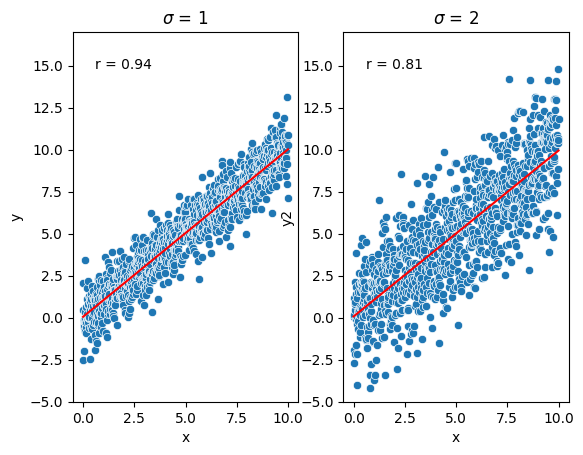

In [38]:
# Is either estimate perfectly correct about the slope and the intercept of the data-generating process? No, but they're not far off. 
# Let's also notice what changed most in our models - the result called rvalue. This is r, the regression coefficient. It makes sense 
# that when our data is noisier- it varies more from a straight line- this measure of the "fit" of the line will be lower.

# To tie everything together, let's plot our estimated regression lines on top of the data, with r displayed:
fig, axs = plt.subplots(1, 2)

# Plot on the first subplot
axs[0].set_title('$\sigma$ = 1')   
sns.scatterplot(x='x', y='y', data=df, ax=axs[0])
sns.lineplot(x='x', y=results1.intercept + results1.slope*df.x, data=df, color='red', ax=axs[0])
axs[0].text(0.1, 0.9, f'r = {results1.rvalue:.2f}', transform=axs[0].transAxes)
axs[0].set_ylim(-5,17)


# Plot on the second subplot
axs[1].set_title('$\sigma$ = 2')
sns.scatterplot(x='x', y='y2', data=df, ax=axs[1])
sns.lineplot(x='x', y=results2.intercept + results2.slope*df.x, data=df, color='red', ax=axs[1])
axs[1].text(0.1, 0.9, f'r = {results2.rvalue:.2f}', transform=axs[1].transAxes)
axs[1].set_ylim(-5,17)


Text(76, 45, 'Scenario 2')

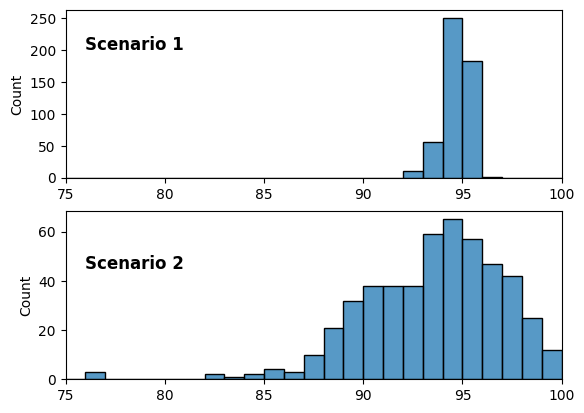

In [39]:
# Probability and Uncertainty

# So far, we've emphasized ways that the properties of a data distribution can help us form expectations about what events are likely. 
# Let's formalize this intuition a bit using some ideas from information theory.

# Imagine that you are looking at the distribution of grades in a class over the last few terms. Here are two different scenarios for how the grade distributions could look:

rng = np.random.default_rng(2)

scenario_1 = stats.gumbel_l(loc = 95, scale = 0.5).rvs(size=500, random_state=rng)
scenario_2 = stats.gumbel_l(loc = 95, scale = 3).rvs(size=500, random_state=rng)

# Let's plot these two scenarios side by side
plt.subplot(2, 1, 1)
sns.histplot(scenario_1, bins=np.arange(75, 101, 1))
plt.xlim(75, 100)
plt.text(76, 200, "Scenario 1", fontsize=12, fontweight='bold')

plt.subplot(2, 1, 2)
sns.histplot(scenario_2, bins=np.arange(75, 101, 1))
plt.xlim(75, 100)
plt.text(76, 45, "Scenario 2", fontsize=12, fontweight='bold')

In [40]:
# If you want to be sure you're going to get an A in class- let's say that means, a 90 or better- which scenario would give you more certainty that you'll end up with an A?
    # In Scenario 1, where our distribution of outcomes (historically) is relatively narrow, that means grades typically fall only within a small range. 
    #               It looks like historically everyone has gotten an A. As long as you expect this pattern will continue to hold, you might be pretty confident you'll also get an A!
    # In Scenario 2 the distribution of outcomes is wider. Not everyone has gotten an A, historically. So- without knowing more about what factors have historically 
    #               been associated with grades- you wouldn't be certain you'll get an A.

# When we're reasoning about the certainty we'll get an A (or any other outcome) based on the shape of the distribution, we're often doing an intuitive calculation 
# that can be formalized through the concept of entropy.

In [41]:
# Introducing Entropy

# The entropy of a random variable is the average level of surprise you have when you see its outcome.

# If the grades are 99% A, then you have very little surprise when an A is realized, but a lot when something else is realized. 
# We're going to quantify the amount of surprise using a mathematical formula.

# This looks a little complicated- but it's not as terrible as it can seem at first. Imagine that we want to know the entropy of the H(x), my letter grade in class.
# Since entropy is defined on categorical variables, let's make our example super simple by breaking down our distributions into 3 categories of grades: A, B, or C.
bins = [70, 80, 90, np.inf]
letter_grades = ["C","B","A"]

# Scenerio 1
df1 = pd.DataFrame({'score': scenario_1})
df1['grade'] = pd.cut(df1['score'], bins, labels=letter_grades)

df1.value_counts('grade')

grade
A    500
C      0
B      0
Name: count, dtype: int64

In [42]:
def calculate_grade_entropy(df):
    letter_grades = df.value_counts('grade').index
    h = 0 
    for letter in letter_grades:
        # Calculate the proportion of students with a grade of letter
        proportion = (df['grade'] == letter).mean()
        if proportion == 0:
            continue
        else:
            log_likelihood = np.log2(proportion)
            h -= proportion * log_likelihood
    return h

# Print the entropy
print("Entropy of scenario 1: ", calculate_grade_entropy(df1))

Entropy of scenario 1:  0.0


In [43]:
# Scenerio 2
df2 = pd.DataFrame({'score': scenario_2})
df2['grade'] = pd.cut(df2['score'], bins, labels=letter_grades)
print(df2.value_counts('grade'))

print("\n\nEntropy of scenario 2: ", calculate_grade_entropy(df2))

grade
A    422
B     75
C      3
Name: count, dtype: int64


Entropy of scenario 2:  0.6613439908145137


<Axes: ylabel='Count'>

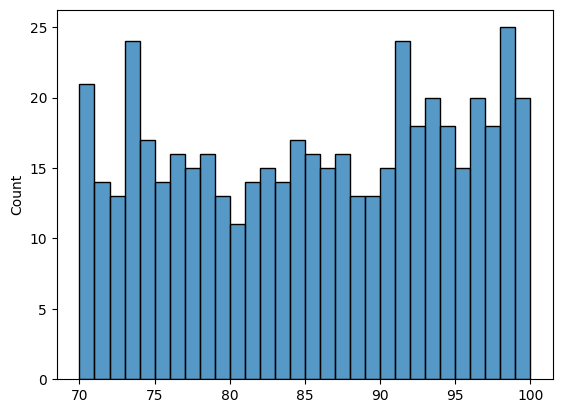

In [44]:
# Entropy and information
# We can see that in Scenario 1, when everyone in class has historically gotten an A, the entropy is 0. Note that it is expressed in bits of 
# information (when we use for our calculation, as above). In other words, when everyone gets an A, the grade variable contains no information!

# When there is some variability in grades- some people get B's and C's- the entropy is higher. The grade conveys more information, on average.

# Maximizing entropy
# As a final thought experiment, let's look at how entropy is maximized. What scenario would give us the most uncertainty about our eventual grade going into a class?

scenario_3 = stats.uniform(loc = 70, scale = 30).rvs(size=500, random_state=rng)

sns.histplot(scenario_3, bins=np.arange(70, 101, 1))

In [45]:
# Save this to a dataframe
df3 = pd.DataFrame({'score': scenario_3})
df3['grade'] = pd.cut(df3['score'], bins, labels=letter_grades)
print(df3.value_counts('grade'))


print("\n\nEntropy of scenario 3: ", calculate_grade_entropy(df3))

grade
A    193
C    163
B    144
Name: count, dtype: int64


Entropy of scenario 3:  1.5744720895818909


In [46]:
# Note that the theoretical maximum of entropy for when there are 3 equally likely outcomes is:
np.log2(3)

np.float64(1.584962500721156)

In [47]:
# The Entropy function

# You will not always have to write your own entropy function- as long as you have a probability mass function to work from, you can use 
# the entropy() function in the scipy.stats module. Here's an example, working directly from a theoretical distribution

# When you define a distribution as a data-generating process in scipy.stats, you can get the entropy of the probability mass function 
# directly. Let's consider the binomial distribution for simulating coin flips:

distribution = stats.binom(n=1, p=0.5) # simulating a coin flip
print(distribution.rvs(size=100, random_state=rng))

pmf = [distribution.pmf(x) for x in range(2)]
print("\n\n",pmf)
print("\n\n",stats.entropy(pmf, base = 2))

[0 0 1 0 1 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0 1 0 0 1 0 0
 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 1 1 0
 1 1 1 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 1]


 [np.float64(0.5000000000000001), np.float64(0.5)]


 0.9999999999999999


In [48]:
# We can use these functions to replicate a classic exploration of entropy with a coin flip experiment. Imagine that we are varying how 
# unfair a coin is- we start with a coin that only ever comes up tails. Then we slowly vary the weighting so it becomes more fair, until 
# it is perfectly fair. And then we keep varying the weighting until it only ever comes up heads. How does the entropy change?

p_range = np.linspace(0, 1, 100)
entropies = []

for p in p_range:
    distribution = stats.binom(n=1, p=p) 
    pmf = [distribution.pmf(x) for x in range(2)]
    entropies.append(stats.entropy(pmf, base = 2))

In [49]:
p_range = np.linspace(0, 1, 100)
entropy = []

for p in p_range:
    distribution = stats.binom(n=1, p=p) 
    pmf = [distribution.pmf(x) for x in range(2)]
    entropy.append(stats.entropy(pmf, base = 2))

<Axes: xlabel='p', ylabel='entropy'>

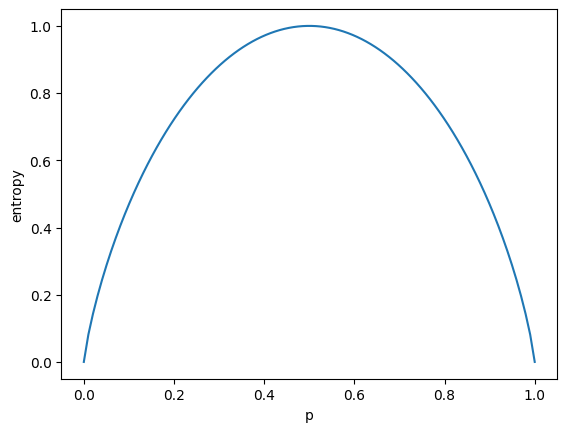

In [50]:
entropies_df = pd.DataFrame({'p': p_range, 'entropy': entropies})
sns.lineplot(data=entropies_df, x='p', y='entropy')

In [51]:
# As show in above figure, when the coin is completely bias at probability of 0 and 1, the entropy is 0, meaning there is no chance of getting other outcome.
# At a the fair point of probability 0.5, the entropy is at its max of 1.0, meaning the chances of getting other outcome is at its highest.